In [2]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Polygon
from transformers import pipeline
from dotenv import load_dotenv
load_dotenv()

from faro import FaroSceneGraphReader
from delaunay import get_delaunay_centerlines, HAS_NUMBA
from traj import (
    OrientedBoundingBox,
    extract_vehicle_chronology,
    get_vehicle_heading,
)
from som import identify_lane_connections

%matplotlib widget
%load_ext autoreload
%autoreload 2

try:
    if string_table:
        pass
except NameError:
    string_table = {}

clf_pipeline = pipeline(
    "zero-shot-classification",
    model="sileod/deberta-v3-large-tasksource-nli",
    local_files_only=True,
)

Device set to use mps:0


In [3]:
folder = '../data/nhtsa-ciss/data/output/'
# load random .far file from folder
far_files = [f for f in os.listdir(folder) if f.endswith('.far')]
filename = random.choice(far_files)
# filename = '23103_20211031066.far'
# filename = '22186_20211027049.far'

# filename = '22012_20211052088.far'
# filename = '21137_20211020024.far'
# filename = '21647_20211022054.far'
# filename = '20544_20211020005.far'
# filename = '27208_20221010147.far'
# filename = '28136_20221019168.far'
# filename = '25922_20221019074.far'
# filename = '21670_20211048031.far'
# filename = '26217_20221059035.far'
# filename = '25486_20221052042.far'
# filename = '26808_20221052111.far'
# filename = '27014_20221018071.far'
# filename = '28274_20221020227.far'
# filename = '25486_20221052042.far'
# filename = '27256_20221059066.far'
# filename = '20407_20211077002.far' # Polyline instead of symbol for cars
# filename = '25962_20221018041.far'

filename = '22362_20211032077.far'  # splitting test
# filename = '21802_20211059022.far'
# filename = '20327_20211029001.far'
filename = '20361_20211016001.far' 

file = os.path.join(folder, filename)
print(f"Loading file: {file}")
print(f"https://crashviewer.nhtsa.dot.gov/ciss/details/{filename.split('_')[0]}/crash-summary-scene-diagram")
reader = FaroSceneGraphReader(file, clf_pipeline, cls_cache=string_table)
scene = reader.parse()
print(len(scene["vehicles"]))

Loading file: ../data/nhtsa-ciss/data/output/20361_20211016001.far
https://crashviewer.nhtsa.dot.gov/ciss/details/20361/crash-summary-scene-diagram


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Extracted 19 primitives and 13 symbols.
Classifying symbols for vehicle candidates...
10
Numba JIT available: True


In [ ]:
for item in scene["misc"]:
    print(item['name'])

None
NorthArrow 07
None


: 

Centerline lengths: min=9.39321083107966, max=36.0


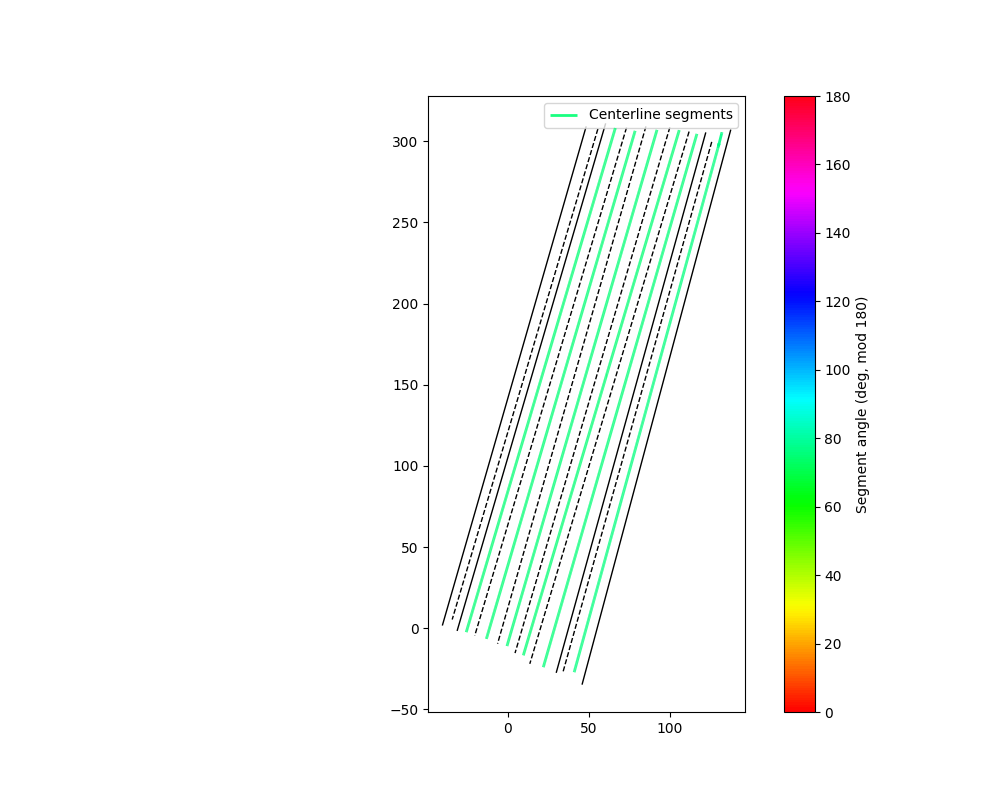

In [17]:
# ============================================================================
# SCENE VISUALIZATION
# ============================================================================
result_centerlines = get_delaunay_centerlines(
    scene["roadway"],
    road_threshold=(8, 36.0),
    vertex_cluster_threshold=10,
    parallel_angle_epsilon=15.0
)

centerline_segments = result_centerlines["centerlines"]
centroid_segments = result_centerlines["skeleton_segments"]
midpoints = result_centerlines["midpoints"]
debug = result_centerlines["debug"]

def draw_symbol(ax, item, color=None):
    if color is None:
        color = np.random.rand(3)
    if item["type"] == "symbol":
        for item in item['items']:
            if item['type'] == 'symbol':
                for subitem in item['items']:
                    verts = subitem["transformed_verts"]
                    xs, ys = zip(*verts)
                    ax.plot(xs, ys, color=color)
            else:
                verts = item["transformed_verts"]
                xs, ys = zip(*verts)
                ax.plot(xs, ys, color=color)
    else:
        verts = item["transformed_verts"]
        xs, ys = zip(*verts)
        ax.plot(xs, ys, color=color)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)



for item in scene["roadway"]:
    verts = item["verts"]
    color = 'black'
    xs, ys = zip(*verts)
    dashed = item.get("dashed", False)
    closed = item.get("closed", False)
    thick = item.get("thick", False)
    if dashed:
        ax.plot(xs, ys, color=color, linestyle='--', linewidth=2 if thick else 1)
    else:
        ax.plot(xs, ys, color=color, linewidth=2 if thick else 1)
        if closed:
            ax.fill(xs, ys, color='lightgray', alpha=0.5)

debug_draw = False
# Calculate min and max lengths from centerline_segments
if centerline_segments:
    all_lengths = [point[2] for line in centerline_segments for point in line]
    min_length = min(all_lengths)
    max_length = max(all_lengths)
    # color = 'none'
    # color = 'length'
    color = 'angle'
    # Prepare segments and their corresponding lengths for coloring
    segments = []
    segment_lengths = []
    for line in centerline_segments:
        for i in range(len(line) - 1):
            x0, y0, l0 = line[i]
            x1, y1, l1 = line[i + 1]
            segments.append([[x0, y0], [x1, y1]])
            # Use the average length for the segment color
            segment_lengths.append((l0 + l1) / 2)
        
        center = np.mean([[point[0], point[1]] for point in line], axis=0)
        
        if debug_draw and len(line) > 1:
            x0, y0, l0 = line[0]
            x1, y1, l1 = line[1]
            dx, dy = x1 - x0, y1 - y0
            mag = np.hypot(dx, dy)
            if mag > 0:
                ux, uy = dx / mag, dy / mag
                segments.append([[x0 - 80 * ux, y0 - 80 * uy], [x0, y0]])
                segment_lengths.append(l0)

            x0, y0, l0 = line[-2]
            x1, y1, l1 = line[-1]
            dx, dy = x1 - x0, y1 - y0
            mag = np.hypot(dx, dy)
            if mag > 0:
                ux, uy = dx / mag, dy / mag
                segments.append([[x1, y1], [x1 + 80 * ux, y1 + 80 * uy]])
                segment_lengths.append(l1)
        
    if color == 'length':
        norm_center = plt.Normalize(vmin=min_length, vmax=max_length)
        colors_center = plt.cm.viridis(norm_center(segment_lengths))
        lc_center = LineCollection(segments, colors=colors_center, linewidths=2, alpha=0.9, zorder=10, label='Centerline segments')
        sm_center = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm_center)
        fig.colorbar(sm_center, ax=ax, label='Road width (ft)')
    elif color == 'angle':
        from matplotlib.colors import hsv_to_rgb
        segment_angles = []
        for seg in segments:
            (x0, y0), (x1, y1) = seg
            angle_deg = np.degrees(np.arctan2(y1 - y0, x1 - x0)) % 180
            segment_angles.append(angle_deg)
        segment_angles = np.array(segment_angles)
        hues = segment_angles / 180.0
        colors_center = [hsv_to_rgb([h, 1.0, 1.0]) for h in hues]
        lc_center = LineCollection(segments, colors=colors_center, linewidths=2, alpha=0.9, zorder=10, label='Centerline segments')
        norm_angle = plt.Normalize(vmin=0, vmax=180)
        sm_angle = plt.cm.ScalarMappable(cmap=plt.cm.hsv, norm=norm_angle)
        fig.colorbar(sm_angle, ax=ax, label='Segment angle (deg, mod 180)')
    else:
        lc_center = LineCollection(segments, color='blue', linewidths=2, alpha=0.9, zorder=10, label='Centerline segments')
        
    ax.add_collection(lc_center)
    print(f"Centerline lengths: min={min_length}, max={max_length}")

debug_draw = False
if debug_draw:
    triangle_segments = debug["triangle_segments"]
    clustered_triangles = debug["clustered_triangles"]
    non_parallel_triangles = debug["non_parallel_triangles"]
    vertex_cluster_info = debug["vertex_cluster_info"]
    debug_points = debug["all_points"]
    centerline_points = debug["all_centerline_points"]

    if centroid_segments:
        lengths = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in centroid_segments])
        if len(lengths) == 0:
            lc_cent = LineCollection(centroid_segments, colors='green', linewidths=1, alpha=0.3)
        else:
            vmin, vmax = lengths.min(), lengths.max()
            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.cm.viridis
            colors_cent = cmap(norm(lengths))
            lc_cent = LineCollection(centroid_segments, colors=colors_cent, linewidths=1, alpha=0.3, label='Centroid connections')
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            fig.colorbar(sm, ax=ax, label='centroid edge length')
        ax.add_collection(lc_cent)
    if triangle_segments:
        lengths_tri = np.array([np.linalg.norm(np.asarray(a) - np.asarray(b)) for a, b in triangle_segments])
        if len(lengths_tri) == 0:
            lc_tri = LineCollection(triangle_segments, colors='green', linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
        else:
            vmin_tri, vmax_tri = lengths_tri.min(), lengths_tri.max()
            norm_tri = plt.Normalize(vmin=vmin_tri, vmax=vmax_tri)
            cmap_tri = plt.cm.viridis
            colors_tri = cmap_tri(norm_tri(lengths_tri))
            lc_tri = LineCollection(triangle_segments, colors=colors_tri, linewidths=0.5, alpha=0.6, label='Valid triangles (parallel)')
            sm_tri = plt.cm.ScalarMappable(cmap=cmap_tri, norm=norm_tri)
            fig.colorbar(sm_tri, ax=ax, label='triangle edge length')
        ax.add_collection(lc_tri)

    # if clustered_triangles:
    #     lc_clustered = LineCollection(clustered_triangles, colors='red', linewidths=1, alpha=0.5, label='Clustered triangles (filtered)')
    #     ax.add_collection(lc_clustered)

    # if debug["oversized_triangles"]:
    #     lc_oversized = LineCollection(debug["oversized_triangles"], colors='pink', linewidths=1, alpha=0.5, label='oversized triangles (width rejected)')
    #     ax.add_collection(lc_oversized)
    
    # if debug["undersized_triangles"]:
    #     lc_undersized = LineCollection(debug["undersized_triangles"], colors='purple', linewidths=1, alpha=0.5, label='Undersized triangles (width rejected)')
    #     ax.add_collection(lc_undersized)

    # if non_parallel_triangles:
    #     lc_non_parallel = LineCollection(non_parallel_triangles, colors='orange', linewidths=1, alpha=0.5, label='Non-parallel triangles (filtered)')
    #     ax.add_collection(lc_non_parallel)

    # if vertex_cluster_info:
    #     problematic_verts = [(debug_points[v_idx], count) for v_idx, count in vertex_cluster_info.items() if count >= 10]
    #     if problematic_verts:
    #         verts, counts = zip(*problematic_verts)
    #         ax.scatter(*zip(*verts), color='darkred', s=100, marker='*', zorder=13,
    #                 label=f'Cluster centers ({len(verts)} vertices)', edgecolors='yellow', linewidths=1)
    if centerline_points:
        ax.scatter(*zip(*centerline_points), color='blue', s=5, marker='x', zorder=12,
                label=f'All Points ({len(centerline_points)} points)')

    # if midpoints:
    #     ax.scatter(*zip(*midpoints), color='blue', s=5, marker='x', zorder=12,
    #             label=f'Midpoints ({len(midpoints)} points)')


# colors = plt.colormaps['Set1']
# for item in scene["vehicles"]:
#     color = np.random.rand(3,)
#     if item["associated_text"]:
#         veh_no = item["associated_text"][0]
#         if veh_no.isdigit():
#             color = colors(int(veh_no) % 5)
#         else:
#             color = np.random.rand(3,)
#     draw_symbol(ax, item, color=color)
#     cx, cy = item["transformed_center"]
#     ax.plot(cx, cy, 'o', color=color)

for item in scene["road_markings"]:
    if not item["name"]:
        continue
    draw_symbol(ax, item)

# ax.axis('off')
ax.legend(loc='upper right')
ax.set_aspect('equal', 'box')

In [4]:
# # Plot angle profiles for all centerline segments in a grid
# result_centerlines = get_delaunay_centerlines(
#     scene["roadway"],
#     road_threshold=(8, 36.0),
#     vertex_cluster_threshold=10,
#     parallel_angle_epsilon=15.0,
# )


# def plot_lane_angles(centerline_segments):
#     num_lanes = len(centerline_segments)
#     cols = 4
#     rows = int(np.ceil(num_lanes / cols))

#     fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows))
#     axes = axes.flatten()

#     for idx, line in enumerate(centerline_segments):
#         angles = []
#         coords = np.array([(p[0], p[1]) for p in line])
#         vectors = np.diff(coords, axis=0)
#         seg_lengths = np.linalg.norm(vectors, axis=1)
#         angles = np.arctan2(vectors[:, 1], vectors[:, 0])
#         angle_diffs = np.abs(np.diff(angles))
#         angle_diffs = np.minimum(angle_diffs, 2 * np.pi - angle_diffs)
#         # Normalize curvature by segment length (average of adjacent segments)
#         avg_lengths = (seg_lengths[:-1] + seg_lengths[1:]) / 2.0
#         curvatures = np.where(avg_lengths > 0, angle_diffs / avg_lengths, 0.0)
#         curvatures_deg = np.degrees(curvatures)
#         ax = axes[idx]
#         ax.plot(range(len(curvatures)), curvatures_deg, "r-o", markersize=3)
#         ax.set_title(f"Lane {idx} ({len(curvatures)} segments)")
#         ax.set_xlabel("Segment Index")
#         ax.set_ylabel("Curvature (deg / ft)")
#         ax.plot(range(len(angles)), np.degrees(angles), "b-o", markersize=3)
#         # ax.set_title(f"Lane {idx} ({len(angles)} segs)")
#         # ax.set_ylabel("Angle (deg)"
#         # )
#         ax.plot(range(len(seg_lengths)), seg_lengths, "g-o", markersize=3)
#         ax.legend(["Curvature", "Angle", "Length"])
#         ax.grid(True, alpha=0.3)


#     # Hide unused subplots
#     for i in range(num_lanes, len(axes)):
#         axes[i].axis("off")

#     plt.tight_layout()
#     plt.show()


# plot_lane_angles(result_centerlines["centerlines"])

In [5]:
# ============================================================================
# VEHICLE TRAJECTORY EXTRACTION (TSP)
# ===========================================================================

PRE_CRASH_ONLY = True  # Set to True: clothoid-only up to first crash, no post-collision fitting

result = extract_vehicle_chronology(scene, pre_crash_only=PRE_CRASH_ONLY)

print(f"\n=== TSP TRAJECTORY ORDERING RESULTS ===")
print(f"Number of vehicle groups: {len(result['trajectories'])}")
print(f"Mode: {'pre-crash only (clothoid)' if PRE_CRASH_ONLY else 'full hybrid (clothoid + spline)'}")

for label, positions in result['trajectories'].items():
    print(f"\nVehicle {label}: {len(positions)} positi/preons")
    print(f"  TSP path score: {result['scores'][label]:.2f}")
    for i, pos in enumerate(positions):
        heading = np.degrees(get_vehicle_heading(pos))
        print(f"    [{i}] center={pos['transformed_center']}, heading={heading:.1f} deg")

if result['first_collisions']:
    fc = result['first_collisions']
    print(f"\n=== FIRST COLLISIONS (per vehicle) ===")
    for label, c in fc['per_vehicle'].items():
        idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]
        other = c['vehicles'][1] if c['vehicles'][0] == label else c['vehicles'][0]
        print(f"  Vehicle {label}: first collision at index {idx} with Vehicle {other} (penetration={c['penetration']:.2f})")
    print(f"  Unique collision events: {len(fc['unique_collisions'])}")
else:
    print("\nNo collision detected between any vehicle positions.")


=== TSP TRAJECTORY ORDERING RESULTS ===
Number of vehicle groups: 3
Mode: pre-crash only (clothoid)

Vehicle 1: 4 positi/preons
  TSP path score: 242.08
    [0] center=(np.float64(-43.2614058760273), np.float64(-235.189129398961)), heading=53.9 deg
    [1] center=(np.float64(-5.39040367876171), np.float64(-185.118954228063)), heading=53.9 deg
    [2] center=(np.float64(42.9370132180584), np.float64(-121.241009281774)), heading=54.0 deg
    [3] center=(np.float64(65.6596084329021), np.float64(-91.1452985273798)), heading=57.7 deg

Vehicle 2: 4 positi/preons
  TSP path score: 166.79
    [0] center=(np.float64(193.501129150391), np.float64(-187.033576488495)), heading=144.0 deg
    [1] center=(np.float64(138.429977416992), np.float64(-145.405707836151)), heading=143.5 deg
    [2] center=(np.float64(101.554267883301), np.float64(-115.847350597382)), heading=144.0 deg
    [3] center=(np.float64(75.4139251708984), np.float64(-95.4357447624207)), heading=144.0 deg

Vehicle 3: 1 positi/preons

In [9]:
# ============================================================================
# VISUALIZATION: Ordered trajectories with OBBs (TSP ordering)
# ============================================================================

def draw_obb(ax, obb, color='blue', alpha=0.3, linewidth=1):
    """Draw an OBB on the matplotlib axis."""
    corners = obb.get_corners()
    polygon = Polygon(corners, closed=True, fill=True,
                      facecolor=color, edgecolor=color,
                      alpha=alpha, linewidth=linewidth)
    ax.add_patch(polygon)
    return polygon

if 'result' in dir() and result is not None:
    fig, ax = plt.subplots(figsize=(12, 10))

    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.3)

    # Build per-vehicle collision cutoff index from first_collisions
    collision_cutoffs = {}
    if result['first_collisions']:
        fc = result['first_collisions']
        for label, c in fc['per_vehicle'].items():
            idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]
            collision_cutoffs[label] = idx

    # Color maps for different vehicles
    vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))
    # Draw each vehicle's trajectory UP TO the first collision
    for vid, (label, positions) in enumerate(result['trajectories'].items()):
        base_color = vehicle_colors(vid)
        n_positions = len(positions)

        # Determine cutoff index if this vehicle is involved in collision
        max_index = collision_cutoffs.get(label, n_positions - 1)

        # Create gradient from light to dark
        for i, pos in enumerate(positions):
            if i > max_index:
                continue

            alpha = 0.2 + 0.6 * (i / max(1, n_positions - 1))

            obb = OrientedBoundingBox.from_vehicle_symbol(pos)
            draw_obb(ax, obb, color=base_color, alpha=alpha, linewidth=2)

            cx, cy = pos["transformed_center"]
            ax.plot(cx, cy, 'o', color=base_color, markersize=8,
                    alpha=alpha, zorder=10)

            ax.annotate(f"{label}[{i}]", (cx, cy),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=8, color=base_color, alpha=0.8)

        # Draw clothoid trajectory curve instead of straight lines
        if label in result['connected']:
            cx_list, cy_list = result['connected'][label]
            if cx_list and cy_list:
                ax.plot(cx_list, cy_list, '-', color=base_color, linewidth=2,
                        alpha=0.7, zorder=5,
                        label=f'Vehicle {label} (score={result["scores"][label]:.1f})')

    # Highlight collision points (all unique first-collision events)
    if result['first_collisions']:
        for c in result['first_collisions']['unique_collisions']:
            # Draw collision OBBs with red
            draw_obb(ax, c['obb1'], color='red', alpha=0.5, linewidth=3)
            draw_obb(ax, c['obb2'], color='red', alpha=0.5, linewidth=3)

            # Draw midpoint
            collision_center = (c['obb1'].center + c['obb2'].center) / 2
            ax.plot(collision_center[0], collision_center[1], 'X',
                    color='red', markersize=15, markeredgewidth=3,
                    zorder=20)

        # Single legend entry for collisions
        ax.plot([], [], 'X', color='red', markersize=15, markeredgewidth=3,
                label=f'Collisions ({len(result["first_collisions"]["unique_collisions"])})')

    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.legend(loc='upper right')
    ax.set_title('Vehicle Trajectories (TSP Ordered) - Clothoid Paths\n(Lighter = earlier, Darker = later)')
    plt.tight_layout()
    plt.show()
else:
    print("No trajectory results to visualize. Run the extraction cell first.")

No trajectory results to visualize. Run the extraction cell first.


Extracted 62 total endpoints from centerlines
LaneEndpoint(id=0, x=np.float64(-58.47018422949133), y=np.float64(-61.89795207578642), heading=np.float64(-0.6597756643286593), lane_idx=0)
Total endpoints: 62
Intersection endpoints: 62


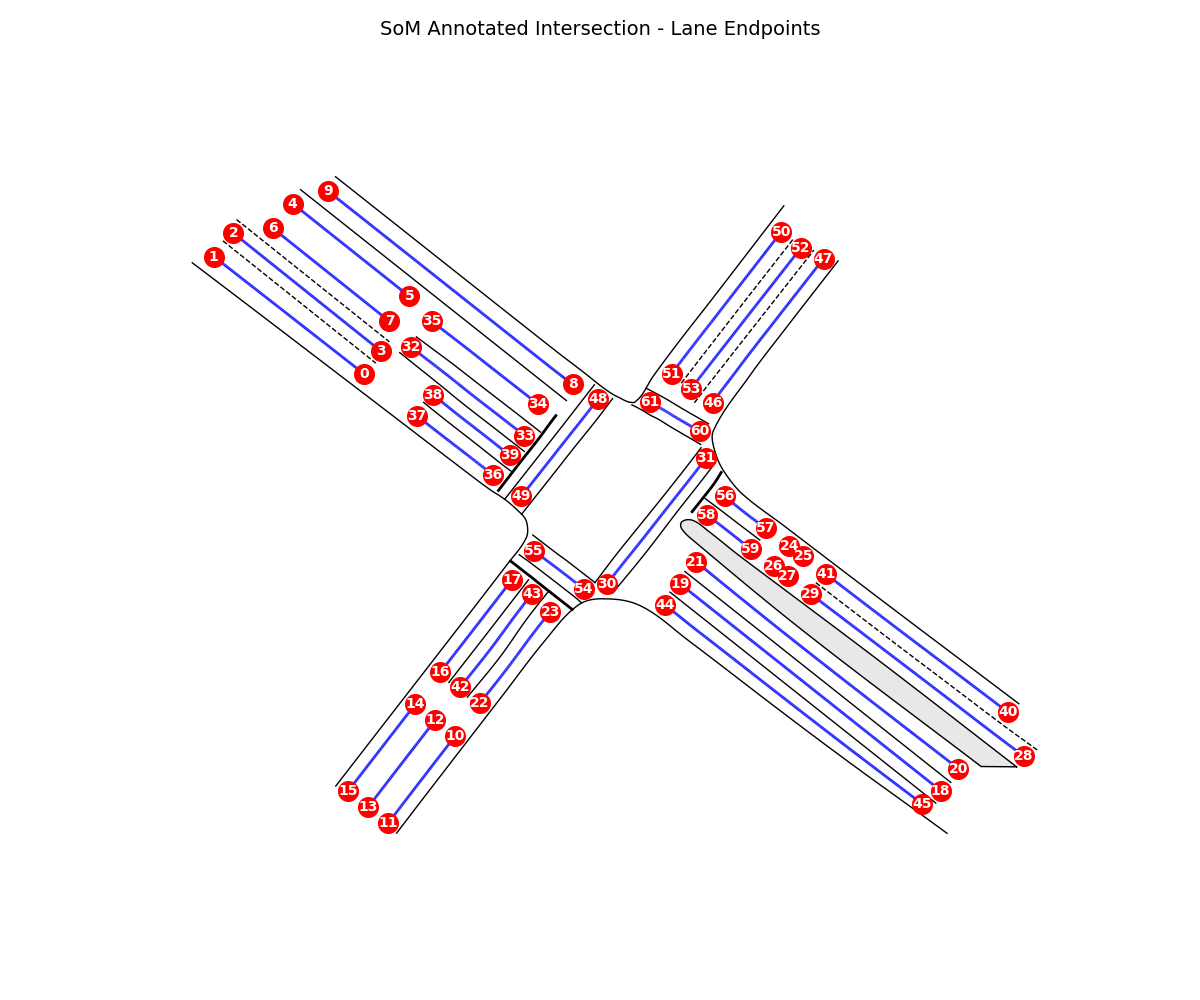


Marked endpoints:
  [0] Lane 0, pos=(-58.5, -61.9)
  [1] Lane 0, pos=(-124.3, -10.5)
  [2] Lane 1, pos=(-115.8, -0.2)
  [3] Lane 1, pos=(-51.2, -51.9)
  [4] Lane 2, pos=(-89.8, 12.7)
  [5] Lane 2, pos=(-38.6, -27.9)
  [6] Lane 3, pos=(-98.4, 1.9)
  [7] Lane 3, pos=(-47.4, -38.9)
  [8] Lane 4, pos=(32.8, -66.5)
  [9] Lane 4, pos=(-74.3, 18.2)
  [10] Lane 5, pos=(-18.5, -220.3)
  [11] Lane 5, pos=(-47.8, -258.4)
  [12] Lane 6, pos=(-27.3, -213.5)
  [13] Lane 6, pos=(-56.7, -251.6)
  [14] Lane 7, pos=(-36.1, -206.7)
  [15] Lane 7, pos=(-65.6, -244.7)
  [16] Lane 8, pos=(-25.1, -192.6)
  [17] Lane 8, pos=(6.2, -152.1)
  [18] Lane 9, pos=(194.0, -244.4)
  [19] Lane 9, pos=(79.9, -153.9)
  [20] Lane 10, pos=(201.7, -234.7)
  [21] Lane 10, pos=(86.9, -144.2)
  [22] Lane 11, pos=(-7.9, -206.2)
  [23] Lane 11, pos=(23.0, -166.2)
  [24] Lane 12, pos=(127.7, -137.1)
  [25] Lane 12, pos=(133.8, -141.8)
  [26] Lane 13, pos=(121.0, -146.0)
  [27] Lane 13, pos=(127.2, -150.6)
  [28] Lane 14, pos=(23

In [7]:
# ============================================================================
# SoM PROMPTING: Lane Connection Identification via VLM
# ============================================================================
# This cell uses Set-of-Mark prompting to identify lane connections at intersections

from som import (
    extract_lane_endpoints,
    create_annotated_figure,
    identify_lane_connections,
    draw_connections,
)

# First, visualize the annotated figure with numbered markers (without VLM)
endpoints, intersection_ids = extract_lane_endpoints(
    centerline_segments,
    cluster_radius=25.0,  # Adjust based on intersection size
)

print(f"Total endpoints: {len(endpoints)}")
print(f"Intersection endpoints: {len(intersection_ids)}")

if intersection_ids:
    # Create and display the annotated figure
    som_fig = create_annotated_figure(
        scene["roadway"],
        centerline_segments,
        endpoints,
        intersection_ids,
        figsize=(12, 10),
        marker_size=200,
        font_size=10,
    )
    som_fig.suptitle("SoM Annotated Intersection - Lane Endpoints", fontsize=14)
    plt.show()
    
    # Print endpoint info
    print("\nMarked endpoints:")
    for ep in endpoints:
        if ep.id in intersection_ids:
            print(f"  [{ep.id}] Lane {ep.lane_idx}, pos=({ep.x:.1f}, {ep.y:.1f})")
else:
    print("No intersection detected - endpoints don't cluster from multiple lanes")

Extracted 62 total endpoints from centerlines
LaneEndpoint(id=0, x=np.float64(-58.47018422949133), y=np.float64(-61.89795207578642), heading=np.float64(-0.6597756643286593), lane_idx=0)


APIConnectionError: Connection error.

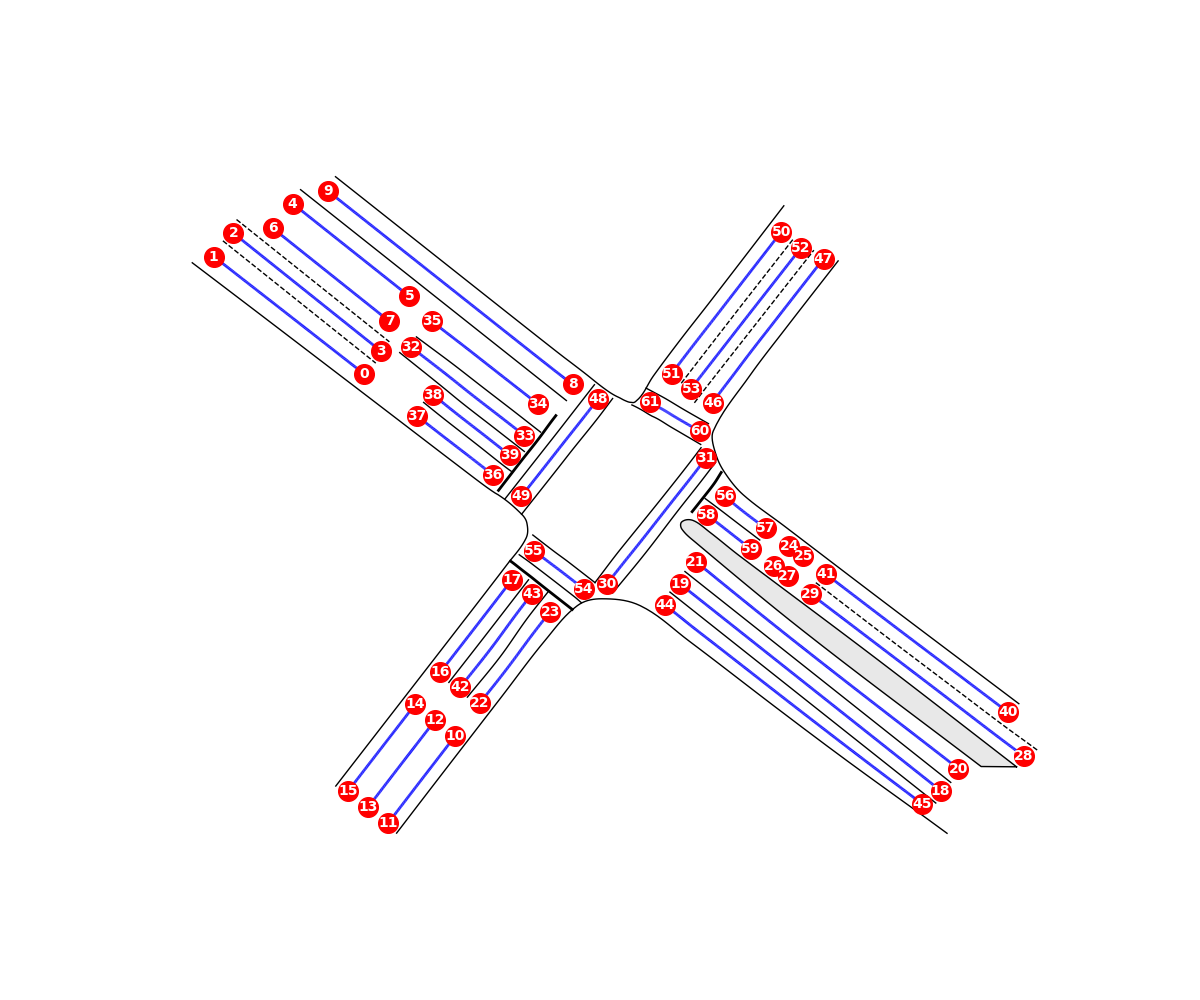

In [8]:
# ============================================================================
# VLM Query for Lane Connections (requires API key)
# ============================================================================
# Uncomment and configure to query the VLM


# Configuration - adjust these for your setup
VLM_CONFIG = {
    # For local Qwen via llama-server:
    # "base_url": "http://192.168.68.70:8000/v1",
    "base_url": "http://localhost:8080/v1",
    # "model": "Qwen/Qwen3-VL-32B-Thinking-FP8",
    "model": "Qwen3-VL-32B-Thinking-Q8_0.gguf",
    # "model": "Qwen3-VL-30B-A3B-Instruct-AWQ",
    "api_key": "not-needed",  # llama-server doesn't require auth
    
    # For OpenAI GPT-4o:
    # "base_url": "https://api.openai.com/v1",
    # "model": "gpt-4o",
    # "api_key": os.environ.get("OPENAI_API_KEY"),
}



# Uncomment to run the VLM query:
result_som = identify_lane_connections(
    roadway=scene["roadway"],
    centerlines=centerline_segments,
    api_key=VLM_CONFIG["api_key"],
    base_url=VLM_CONFIG["base_url"],
    model=VLM_CONFIG["model"],
    cluster_radius=25.0,
    debug=True,
)

print(f"Identified {len(result_som['connections'])} connections:")
for conn in result_som['connections']:
    print(f"  {conn.from_id} -> {conn.to_id}")

if result_som.get('raw_response'):
    print(f"\nRaw VLM response:\n{result_som['raw_response']}")

Curves: 23/23 collision-free


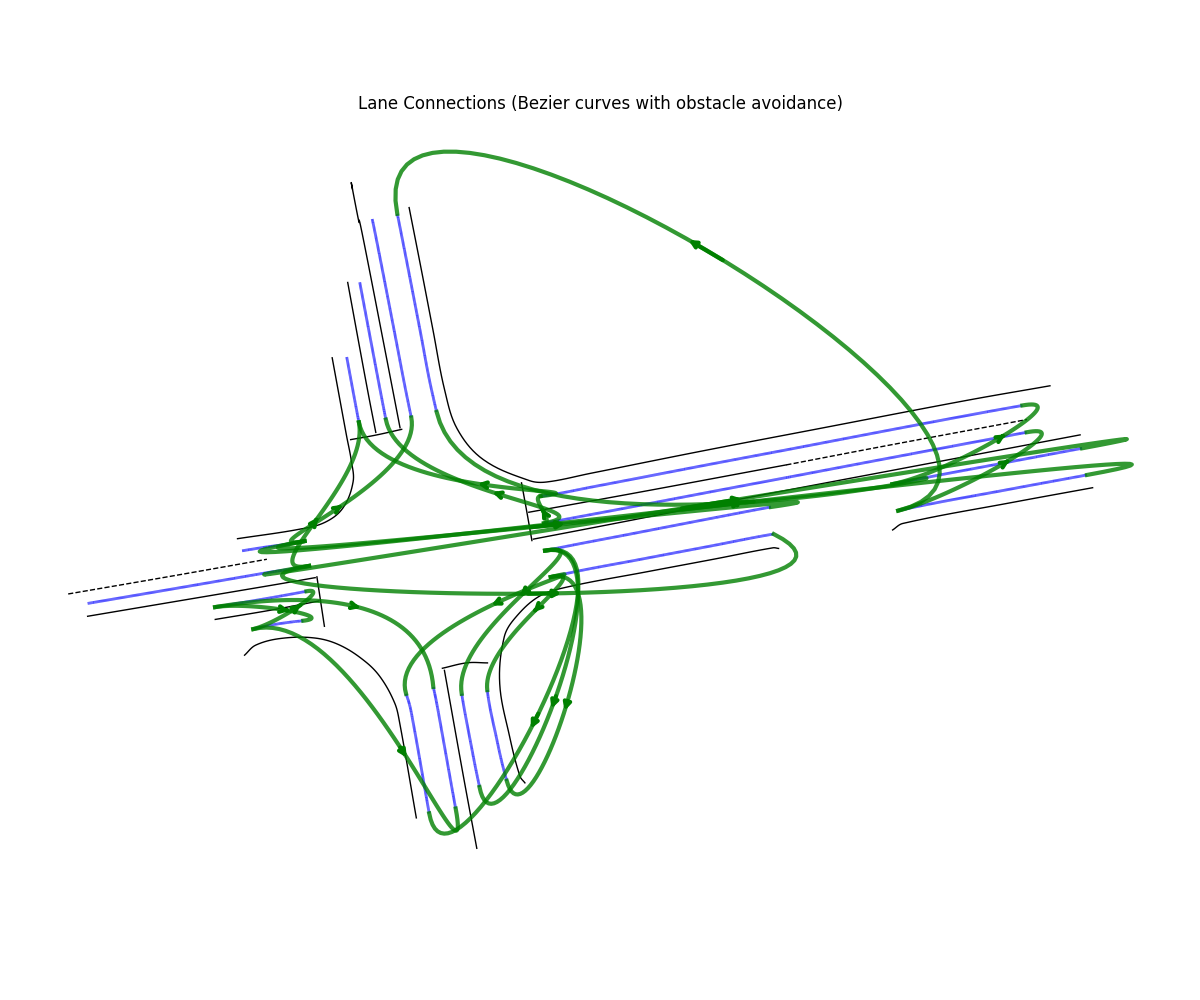

In [ ]:
# ============================================================================
# Visualize Lane Connections with Bezier Curves
# ============================================================================
# Run this after the VLM query cell above

# Uncomment after running VLM query:
if 'result_som' in dir() and result_som.get('connections'):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.5)
    
    # Draw centerlines
    from matplotlib.collections import LineCollection
    segments = []
    for lane in centerline_segments:
        for i in range(len(lane) - 1):
            x0, y0, _ = lane[i]
            x1, y1, _ = lane[i + 1]
            segments.append([[x0, y0], [x1, y1]])
    lc = LineCollection(segments, color='blue', linewidths=2, alpha=0.7, zorder=5)
    ax.add_collection(lc)
    
    # Draw connections with Bezier curves and obstacle avoidance
    curve_data = draw_connections(
        ax,
        result_som['connections'],
        result_som['endpoints'],
        roadway=scene["roadway"],
        color='green',
        linewidth=3,
        alpha=0.8,
        use_bezier=True,
        avoid_obstacles=True,
    )
    
    # Report collision status
    collision_free_count = sum(1 for v in curve_data.values() if v['collision_free'])
    print(f"Curves: {collision_free_count}/{len(curve_data)} collision-free")
    
    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.set_title('Lane Connections (Bezier curves with obstacle avoidance)')
    plt.tight_layout()
    plt.show()
else:
    print("Run the VLM query cell first to get connections")

In [ ]:
# ============================================================================
# VISUALIZATION: Full Crash Reconstruction (Pre + Post Collision)
# ============================================================================

from traj import MotionPhase

if 'result' in dir() and result is not None and result.get('fitted_trajectories'):
    fig, ax = plt.subplots(figsize=(12, 10))

    # Draw roadway
    for item in scene["roadway"]:
        verts = item["verts"]
        xs, ys = zip(*verts)
        dashed = item.get("dashed", False)
        closed = item.get("closed", False)
        if dashed:
            ax.plot(xs, ys, color='black', linestyle='--', linewidth=1)
        else:
            ax.plot(xs, ys, color='black', linewidth=1)
            if closed:
                ax.fill(xs, ys, color='lightgray', alpha=0.3)

    vehicle_colors = plt.cm.get_cmap('tab10', len(result['trajectories']))

    for vid, (label, positions) in enumerate(result['trajectories'].items()):
        base_color = vehicle_colors(vid)
        n_positions = len(positions)
        segments = result['fitted_trajectories'].get(label, [])

        # Determine collision cutoff for this vehicle
        collision_idx = None
        if result['first_collisions']:
            fc = result['first_collisions']
            if label in fc['per_vehicle']:
                c = fc['per_vehicle'][label]
                collision_idx = c['indices'][0] if c['vehicles'][0] == label else c['indices'][1]

        # Draw all OBBs with phase-based styling
        for i, pos in enumerate(positions):
            is_post = collision_idx is not None and i > collision_idx
            alpha = 0.2 + 0.6 * (i / max(1, n_positions - 1))
            edge_color = 'darkorange' if is_post else base_color

            obb = OrientedBoundingBox.from_vehicle_symbol(pos)
            corners = obb.get_corners()
            polygon = Polygon(corners, closed=True, fill=True,
                              facecolor=base_color if not is_post else 'moccasin',
                              edgecolor=edge_color,
                              alpha=alpha, linewidth=2,
                              linestyle='--' if is_post else '-')
            ax.add_patch(polygon)

            cx, cy = pos["transformed_center"]
            marker = 's' if is_post else 'o'
            ax.plot(cx, cy, marker, color=edge_color, markersize=8,
                    alpha=alpha, zorder=10)

            phase_label = "post" if is_post else ""
            ax.annotate(f"{label}[{i}]{phase_label}", (cx, cy),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, color=edge_color, alpha=0.8)

        # Draw fitted trajectory segments by phase
        for seg in segments:
            if seg.path is None or len(seg.path) == 0:
                continue

            xs = seg.path[:, 0]
            ys = seg.path[:, 1]

            if seg.phase == MotionPhase.NORMAL_DRIVING:
                ax.plot(xs, ys, '-', color=base_color, linewidth=2,
                        alpha=0.7, zorder=5)
            elif seg.phase == MotionPhase.POST_COLLISION:
                ax.plot(xs, ys, '--', color='darkorange', linewidth=2.5,
                        alpha=0.8, zorder=6)
                # Draw heading arrows along post-crash path to show spin
                step = max(1, len(seg.path) // 8)
                for k in range(0, len(seg.path), step):
                    x, y, theta = seg.path[k, 0], seg.path[k, 1], seg.path[k, 2]
                    dx = np.cos(theta) * 3
                    dy = np.sin(theta) * 3
                    ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                                arrowprops=dict(arrowstyle='->', color='darkorange',
                                                lw=1.5, alpha=0.6))

        # Legend entry per vehicle
        ax.plot([], [], '-', color=base_color, linewidth=2,
                label=f'V{label} pre-crash (clothoid, score={result["scores"][label]:.1f})')
        has_post = any(s.phase == MotionPhase.POST_COLLISION for s in segments)
        if has_post:
            ax.plot([], [], '--', color='darkorange', linewidth=2.5,
                    label=f'V{label} post-crash (spline)')

    # Highlight collision points
    if result['first_collisions']:
        for c in result['first_collisions']['unique_collisions']:
            draw_obb(ax, c['obb1'], color='red', alpha=0.5, linewidth=3)
            draw_obb(ax, c['obb2'], color='red', alpha=0.5, linewidth=3)
            collision_center = (c['obb1'].center + c['obb2'].center) / 2
            ax.plot(collision_center[0], collision_center[1], 'X',
                    color='red', markersize=15, markeredgewidth=3, zorder=20)

        ax.plot([], [], 'X', color='red', markersize=15, markeredgewidth=3,
                label=f'Collision ({len(result["first_collisions"]["unique_collisions"])})')

    ax.set_aspect('equal', 'box')
    ax.axis('off')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title('Full Crash Reconstruction: Pre-crash (clothoid) + Post-crash (spline)\n'
                 'Solid = pre-crash | Dashed = post-crash | Arrows = heading during slide/spin')
    plt.tight_layout()
    plt.show()
else:
    print("No fitted trajectory results. Run extraction cell with PRE_CRASH_ONLY=False.")